<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [4]:
#!pip install -q gdown torch transformers transformers accelerate bitsandbytes langchain sentence-transformers faiss-gpu openpyxl datasets langchain-community ragatouille umap-learn

In [5]:

# from langchain.docstore.document import Document as LangchainDocument
# from langchain.vectorstores import FAISS
# from langchain_community.embeddings import HuggingFaceEmbeddings
# from langchain_community.vectorstores.utils import DistanceStrategy
# from ragatouille import RAGPretrainedModel
# from sentence_transformers import SentenceTransformer

#------------------------------------------------------------------------------------
# from langchain.text_splitter import ... # выберите другую стратегию разбивки на чанки

# pd.set_option("display.max_colwidth", None)

## Загрузка данных (4 балла)

In [6]:
url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = r'C:\prj\data\points_of_interest\file.csv'

# gdown.download(url, output, quiet=False)

In [7]:
import pandas as pd

In [8]:
df = pd.read_csv(output)

In [9]:
df.head()

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14634 entries, 0 to 14633
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   14634 non-null  int64  
 1   Name         14634 non-null  object 
 2   WikiData     12078 non-null  object 
 3   City         14634 non-null  object 
 4   Lon          14634 non-null  float64
 5   Lat          14634 non-null  float64
 6   description  12078 non-null  object 
 7   image        14634 non-null  object 
 8   en_txt       14634 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 1.0+ MB


In [11]:
df.columns

Index(['Unnamed: 0', 'Name', 'WikiData', 'City', 'Lon', 'Lat', 'description',
       'image', 'en_txt'],
      dtype='object')

In [12]:
df.rename(columns={'Unnamed: 0': 'Num'}, inplace=True)

In [13]:
df

,Num,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...
...,...,...,...,...,...,...,...,...,...
14629,4367,Ярославское художественное училище,Q4538931,Ярославль,39.876846,57.609852,Ярославское художественное училище,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a statue of a man on a staircase in a...
14630,4368,Ярославское художественное училище,Q4538931,Ярославль,39.876846,57.609852,Ярославское художественное училище,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large red brick building with many ...
14631,4369,Ярославское художественное училище,Q4538931,Ярославль,39.876846,57.609852,Ярославское художественное училище,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are statues on the wall of a building wi...
14632,4370,Ярославское художественное училище,Q4538931,Ярославль,39.876846,57.609852,Ярославское художественное училище,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,cars are parked in front of a large brick buil...


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [14]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [15]:
def get_image(data):
    image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
    return image

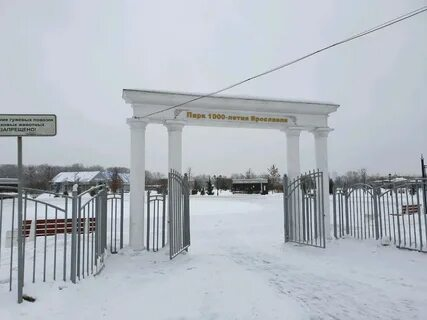

In [16]:
get_image(df.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

### Первоначальная очистка

In [17]:
df['description'] = df['description'].fillna('')
df['en_txt'] = df['en_txt'].fillna('')

> Очистим корпус от лишних пробелов

In [18]:
df['description'] = df['description'].str.strip()
df['en_txt'] = df['en_txt'].str.strip()

> Считаем количество пустых записей с описанием

In [19]:
(df['description'] == '').sum()

2556

> Описание фотографий не пустое

In [20]:
(df['en_txt'] == '').sum()

0

In [21]:
print("Найдено записи с пустым описанием (%):  ",
      round((df['description'] == '').sum() / df.shape[0] * 100, 1))

Найдено записи с пустым описанием (%):   17.5


Посмотрим какие параметры пустые при пустом описаниии

In [22]:
df[df['description'] == ''].nunique()

Num            2500
Name             71
WikiData          0
City              2
Lon              74
Lat              73
description       1
image          2404
en_txt         2230
dtype: int64

> Name, City, WikiData разрежены при пустом описании

**Предполагаем что это дополнительные фотографии, ценность которых сомнительна**

Рассмотрим конкретные записи при пустом desc

In [23]:
df[df['description'] == ''][['Name', 'WikiData', 'description', 'en_txt']].sample(10)

,Name,WikiData,description,en_txt
9921,2000 летию Рождества Христова,NaN,,a close up of a coin with a picture of four me...
9643,Великая Княгиня Ольга,NaN,,a picture of a picture of a woman in a nun's o...
8892,Бобёр,NaN,,a man with a beard and a black shirt is lookin...
8909,Бобёр,NaN,,there is a man sitting at a table with a watch...
10039,"Притвор-часовня в честь иконы Божией Матери ""И...",NaN,,a close up of a painting of a woman and child ...
10073,Ивановский вал,NaN,,snowy scene of a building with a staircase and...
8258,Старый Владимир,NaN,,arafed view of a street with a bus and cars on it
8992,Каменная горка,NaN,,nighttime view of a highway with a city skylin...
8172,Владимирский областной театр кукол,NaN,,there is a building with a lot of windows on t...
11939,Музей занимательных наук Эйнштейна,NaN,,there is a man standing outside of a building ...


> Большинство записей имеют не конкретное название

Посмотрим примеры фото по найденным индексам

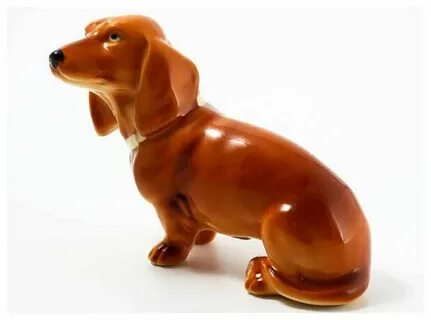

In [24]:
get_image(df.at[9346, 'image'])

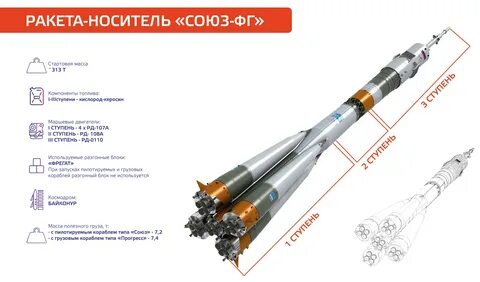

In [25]:
get_image(df.at[9800, 'image'])

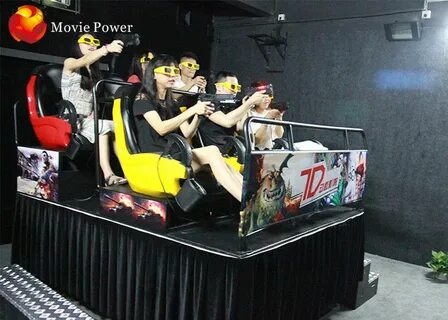

In [26]:
get_image(df.at[9584, 'image'])

> Фото тоже имеет содержание которое слабо относится к достопримечательностям

**Принимаем решение удалить записи с пустым description и WikiData**

In [27]:
df = df[df['description'] != '']

### Статистика по датасету

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12078 entries, 0 to 14633
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Num          12078 non-null  int64  
 1   Name         12078 non-null  object 
 2   WikiData     12078 non-null  object 
 3   City         12078 non-null  object 
 4   Lon          12078 non-null  float64
 5   Lat          12078 non-null  float64
 6   description  12078 non-null  object 
 7   image        12078 non-null  object 
 8   en_txt       12078 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 943.6+ KB


### Поле Num

In [29]:
df.Num.describe()

count    12078.000000
mean      1810.912651
std       1169.944608
min          0.000000
25%        775.250000
50%       1722.500000
75%       2821.000000
max       4371.000000
Name: Num, dtype: float64

In [30]:
df.Num.unique().shape[0]

4372

In [31]:
def frequency_distribution(s: pd.Series):
    value_counts = s.value_counts()
    duplicate_counts = value_counts[value_counts > 1]
    plt.figure(figsize=(6, 3))

    frequency_distribution = duplicate_counts.value_counts().sort_index()
    frequency_distribution.plot(kind='bar', color='salmon', edgecolor='grey')
    plt.title('Распределение частоты дубликатов')
    plt.xlabel('Количество повторений')
    plt.ylabel('Количество значений')
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

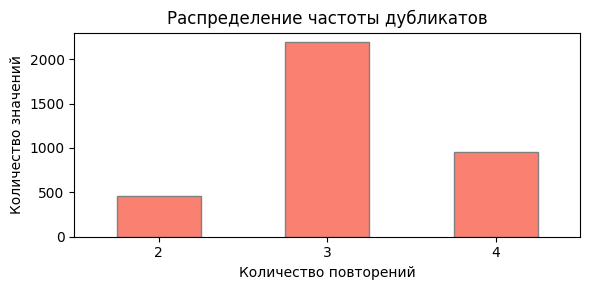

In [32]:
frequency_distribution(df['Num'])

### Поле Name

In [33]:
df['Name'].unique().shape[0]

317

In [34]:
df['Name'].unique()

array(['Динамо', '№32 Дом обороны', 'Дом обороны',
       '№28 Здание городской электростанции «Луч»',
       '№27 Дом Г.Н. Скрябина', 'Литературная жизнь Урала XX века',
       'Дом-музей Бажова', 'Театр кукол', 'Харитоновский сад',
       'Храм в честь Вознесения Господня', 'Суворовское училище',
       'Свято-Троицкий Кафедральный собор',
       'Дом-музей Д. Н. Мамина-Сибиряка',
       'Художественный Музей Эрнста Неизвестного', 'Серго Орджоникидзе',
       'Н. И. Кузнецову', 'Успенский собор на ВИЗе', 'Царский мост',
       'Дом печати (Екатеринбург)', 'Музей изобразительных искусств',
       'Александро-Невский собор', 'Здание бывшей гостиницы "Мадрид"',
       'Екатеринбургский музей изобразительных искусств',
       'Уральский государственный медицинский университет',
       'Центральный стадион', 'Уральская государственная консерватория',
       '№18 Фотографический музей «Дом Метенкова»',
       'Преображенская церковь на Уктусе',
       'Уральский геологический музей', 'Дом 

Сделаем анализ поля Name с помощью LLM:

`Промпт`: Выдели все объекты в городе  наиболее встречаемые. Например,  дом, церковь, башня и т.д.

Выведи в виде списка: ['дома', 'соборы', ... ]

In [35]:
type_freq = ['дом', 'церковь', 'музей', 'памятник', 'собор', 'башня', 'театр',
             'улица', 'парк', 'монастырь', 'усадьба', 'университет', 'мост',
             'храм']

Также выделим редкие объекты но выжные для города

In [36]:
type_rare = ['сад', 'сквер', 'гостиница', 'стадион', 'зоопарк', 'цирк',
             'планетарий']

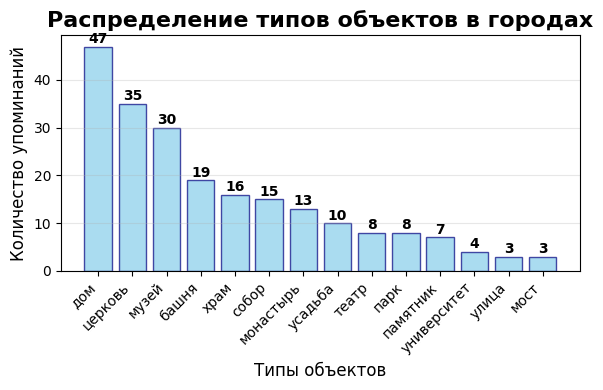

In [37]:
import matplotlib.pyplot as plt
import re

data = df['Name'].unique()


# Функция для поиска вхождений
def count_types_in_data(data, types_list):
    counts = {type_name: 0 for type_name in types_list}
    counts["прочее"] = 0

    for item in data:
        item_lower = item.lower()
        for type_name in types_list:
            # Ищем точные вхождения слов
            if re.search(r'\b' + re.escape(type_name) + r'\b', item_lower):
                counts[type_name] += 1
            else:
                counts["прочее"] += 1

    return counts


# Подсчитываем вхождения
type_counts = count_types_in_data(data, type_freq)
etc_count = type_counts.pop('прочее')

# Сортируем по убыванию частоты
sorted_types = sorted(type_counts.items(), key=lambda x: x[1], reverse=True)
types, counts = zip(*sorted_types)

# Строим график
plt.figure(figsize=(6, 4))
bars = plt.bar(types, counts, color='skyblue', edgecolor='navy', alpha=0.7)

# Добавляем значения на столбцы
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             str(count), ha='center', va='bottom', fontweight='bold')

plt.title('Распределение типов объектов в городах', fontsize=16,
          fontweight='bold')
plt.xlabel('Типы объектов', fontsize=12)
plt.ylabel('Количество упоминаний', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

### Поле WikiData

In [38]:
df.WikiData.unique().shape[0]

296

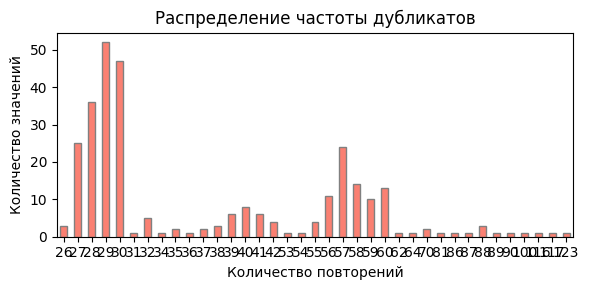

In [39]:
frequency_distribution(df['WikiData'])

### Поле City

In [40]:
df.City.unique().shape[0]

4

In [41]:
df.City.unique()

array(['Екатеринбург', 'Нижний Новгород', 'Владимир', 'Ярославль'],
      dtype=object)

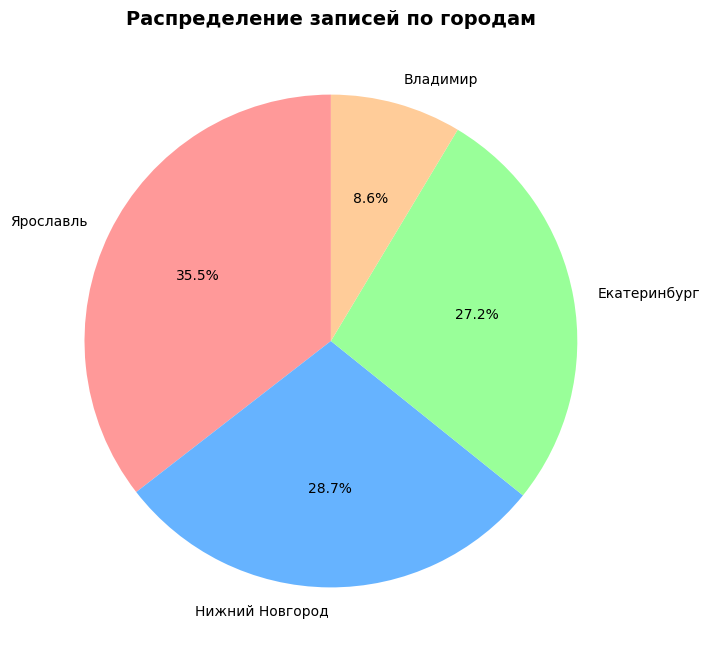

In [42]:
# Круговая диаграмма
plt.figure(figsize=(8, 8))

city_counts = df['City'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']

plt.pie(city_counts.values, labels=city_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Распределение записей по городам', fontsize=14, fontweight='bold')

plt.show()

> Всего 4 города с перекосом распределения

### Поле description

In [43]:
df.description.unique().shape[0]

245

> Всего по всему датасету 245 уникальных описаний
>
> Это и есть конкретные достопримечательности во всех городах

In [44]:
df.description.unique()

array(['спорткомплекс в Екатеринбурге', 'здание в Екатеринбурге',
       'здание и достопримечательность в Екатеринбурге',
       'Дом Е.Д. Скрябиной', 'Музей',
       'Мемориальный дом-музей П. П. Бажова', 'кинотеатр в Екатеринбурге',
       'парк в Екатеринбурге', 'Храм Вознесения Господня (Екатеринбург)',
       'военно-учебное заведение в Екатеринбурге',
       'Троицкий собор (Екатеринбург)',
       'Литературно-мемориальный дом-музей Д. Н. Мамина-Сибиряка',
       'музей в Екатеринбурге', 'Памятник в Екатеринбурге',
       'Успенский собор (Екатеринбург)',
       'мост через Исеть в Екатеринбурге',
       'православный собор в Екатеринбурге', 'гостиница в Екатеринбурге',
       'высшее учебное заведение в Екатеринбурге',
       'стадион в Екатеринбурге', 'Преображенская церковь',
       'Второй Дом Советов (Екатеринбург)', 'сооружение в Екатеринбурге',
       'оперный театр в Екатеринбурге', 'памятник в Екатеринбурге',
       'геологический и археологический памятник природы в Ек

Построим распределение типов достопримечательностей по всему датасету

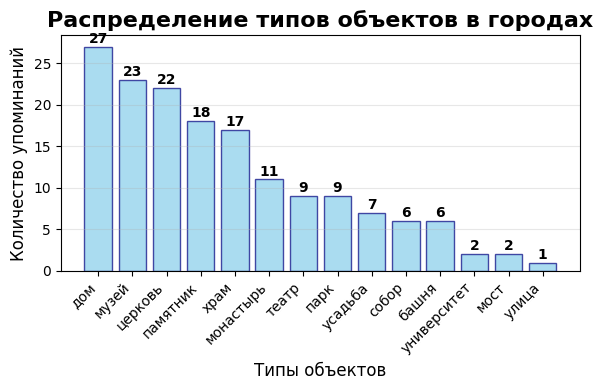

In [45]:
import re
import matplotlib.pyplot as plt

data = df['description'].unique()


# Функция для поиска вхождений
def count_types_in_data(data, types_list):
    counts = {type_name: 0 for type_name in types_list}

    for item in data:
        item_lower = item.lower()
        for type_name in types_list:
            # Ищем точные вхождения слов
            if re.search(r'\b' + re.escape(type_name) + r'\b', item_lower):
                counts[type_name] += 1

    return counts


# Подсчитываем вхождения
type_counts = count_types_in_data(data, type_freq)

# Сортируем по убыванию частоты
sorted_types = sorted(type_counts.items(), key=lambda x: x[1], reverse=True)
types, counts = zip(*sorted_types)

# Строим график
plt.figure(figsize=(6, 4))
bars = plt.bar(types, counts, color='skyblue', edgecolor='navy', alpha=0.7)

# Добавляем значения на столбцы
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             str(count), ha='center', va='bottom', fontweight='bold')

plt.title('Распределение типов объектов в городах', fontsize=16,
          fontweight='bold')
plt.xlabel('Типы объектов', fontsize=12)
plt.ylabel('Количество упоминаний', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

#### Смысловой анализ описания привязанного к городу

Выведем все описания привязанные к городу

In [46]:
def build_dichotomy_scheme_detailed(df):
    scheme = {}

    for city in df['City'].unique():
        city_data = df[df['City'] == city]
        descriptions = city_data['description'].unique()
        scheme[city] = {}

        for desc in descriptions:
            elements = city_data[city_data['description'] == desc]['Name'].tolist()
            scheme[city][desc] = len(elements)

    return scheme

def print_detailed_scheme(scheme):
    for city in scheme:
        print(f"\n### **{city}**")
        print("```")
        descriptions = list(scheme[city].keys())
        for i, desc in enumerate(descriptions):
            num = scheme[city][desc]
            if i == len(descriptions) - 1:
                print(f"└── {desc} {num}")
            else:
                print(f"├── {desc} {num}")
        print("```")

# Использование
scheme = build_dichotomy_scheme_detailed(df)
print_detailed_scheme(scheme)


### **Екатеринбург**
```
├── спорткомплекс в Екатеринбурге 41
├── здание в Екатеринбурге 287
├── здание и достопримечательность в Екатеринбурге 55
├── Дом Е.Д. Скрябиной 28
├── Музей 27
├── Мемориальный дом-музей П. П. Бажова 29
├── кинотеатр в Екатеринбурге 40
├── парк в Екатеринбурге 31
├── Храм Вознесения Господня (Екатеринбург) 57
├── военно-учебное заведение в Екатеринбурге 32
├── Троицкий собор (Екатеринбург) 30
├── Литературно-мемориальный дом-музей Д. Н. Мамина-Сибиряка 29
├── музей в Екатеринбурге 285
├── Памятник в Екатеринбурге 116
├── Успенский собор (Екатеринбург) 29
├── мост через Исеть в Екатеринбурге 69
├── православный собор в Екатеринбурге 27
├── гостиница в Екатеринбурге 29
├── высшее учебное заведение в Екатеринбурге 58
├── стадион в Екатеринбурге 40
├── Преображенская церковь 57
├── Второй Дом Советов (Екатеринбург) 30
├── сооружение в Екатеринбурге 78
├── оперный театр в Екатеринбурге 40
├── памятник в Екатеринбурге 204
├── геологический и археологический памятни

Списки имеют в составе явные абстрактные названия, которые слабо описывают конкретные достопримечательности. Постоим списки не конкретных объектов для каждого города с помощью LLM.

**Промпт**: Дан список объектов в городе. Выдели в отдельный список python  все не конкретные объекты.

Пример не конкретных объектов в городе:
- здание в Екатеринбурге
- Музей
- Памятник в Екатеринбурге

Пример  хорошо идентифицированных объектов в городе :
- Дом Е.Д. Скрябиной
- Мемориальный дом-музей П. П. Бажова

Не включай в список значимые места в городе пример
- спорткомплекс
- гостиница
- мост
- университет

список объектов в городе: ...

**Екатеринбург**
```
├── спорткомплекс в Екатеринбурге
├── здание в Екатеринбурге
├── здание и достопримечательность в Екатеринбурге
├── Дом Е.Д. Скрябиной
├── Музей
├── Мемориальный дом-музей П. П. Бажова
├── кинотеатр в Екатеринбурге
├── парк в Екатеринбурге
├── Храм Вознесения Господня (Екатеринбург)
├── военно-учебное заведение в Екатеринбурге
├── Троицкий собор (Екатеринбург)
├── Литературно-мемориальный дом-музей Д. Н. Мамина-Сибиряка
├── музей в Екатеринбурге
├── Памятник в Екатеринбурге
├── Успенский собор (Екатеринбург)
├── мост через Исеть в Екатеринбурге
├── православный собор в Екатеринбурге
├── гостиница в Екатеринбурге
├── высшее учебное заведение в Екатеринбурге
├── стадион в Екатеринбурге
├── Преображенская церковь
├── Второй Дом Советов (Екатеринбург)
├── сооружение в Екатеринбурге
├── оперный театр в Екатеринбурге
├── памятник в Екатеринбурге
├── геологический и археологический памятник природы в Екатеринбурге
├── Дом контор
├── часовня в Екатеринбурге
├── комплекс зданий в стиле конструктивизма
├── церковь в Екатеринбурге
├── профессиональное учебное заведение Екатеринбурга
├── главная площадь Екатеринбурга
├── Музей кукол и детской книги «Страна чудес»
├── здание в Железнодорожном районе Екатеринбурга
├── Екатеринбургское художественное училище им. И. Д. Шадра
├── концертный зал в Екатеринбурге
├── учебное заведение в Екатеринбурге
├── Музей истории плодового садоводства Среднего Урала
├── Литературно-мемориальный дом-музей Ф. М. Решетникова
├── православный храм в Екатеринбурге
├── Ново-Тихвинский монастырь
├── Дом купца Чувильдина
├── Свердловский областной краеведческий музей
├── музыкальный театр в Екатеринбурге
├── Дом актёра (Екатеринбург)
├── улица в Екатеринбурге
├── Мемориальный комплекс в Екатеринбурге
├── металлургический завод (XVIII век)
├── предприятие в Екатеринбурге
├── Усадьба Железнова
├── Усадьба ротмистра Переяславцева
├── Комплекс штаба военного округа
├── университет в Екатеринбурге
├── бывшее название университета в Екатеринбурге
├── городская площадь в Екатеринбурге
├── Усадьба Тарасова
├── Здание пансиона и церкви Святой Магдалины при первой женской гимназии
├── Дом Бревновых
├── деревянный особняк начала XX века на Вознесенской горке в Екатеринбурге
├── историческое здание в Екатеринбурге
├── Крестовоздвиженская церковь (Екатеринбург)
├── Литературный музей в Екатеринбурге
├── Библиотека в Екатеринбурге
├── Дом Гайдара
└── Дом дворянки Е. О. Селивановой
```

In [47]:
non_specific_objects_ecat = {
    "здание в Екатеринбурге",
    "Музей",
    "Памятник в Екатеринбурге",
    "спорткомплекс в Екатеринбурге",
    "здание и достопримечательность в Екатеринбурге",
    "кинотеатр в Екатеринбурге",
    "парк в Екатеринбурге",
    "военно-учебное заведение в Екатеринбурге",
    "музей в Екатеринбурге",
    "мост через Исеть в Екатеринбурге",
    "православный собор в Екатеринбурге",
    "гостиница в Екатеринбурге",
    "высшее учебное заведение в Екатеринбурге",
    "стадион в Екатеринбурге",
    "сооружение в Екатеринбурге",
    "оперный театр в Екатеринбурге",
    "памятник в Екатеринбурге",
    "геологический и археологический памятник природы в Екатеринбурге",
    "часовня в Екатеринбурге",
    "комплекс зданий в стиле конструктивизма",
    "церковь в Екатеринбурге",
    "профессиональное учебное заведение Екатеринбурга",
    "главная площадь Екатеринбурга",
    "здание в Железнодорожном районе Екатеринбурга",
    "концертный зал в Екатеринбурге",
    "учебное заведение в Екатеринбурге",
    "православный храм в Екатеринбурге",
    "музыкальный театр в Екатеринбурге",
    "улица в Екатеринбурге",
    "Мемориальный комплекс в Екатеринбурге",
    "металлургический завод (XVIII век)",
    "предприятие в Екатеринбурге",
    "университет в Екатеринбурге",
    "бывшее название университета в Екатеринбурге",
    "городская площадь в Екатеринбурге",
    "деревянный особняк начала XX века на Вознесенской горке в Екатеринбурге",
    "историческое здание в Екатеринбурге",
    "Литературный музей в Екатеринбурге",
    "Библиотека в Екатеринбурге"
    }

non_specific_objects_rare_ecat = {
    "спорткомплекс в Екатеринбурге",
    "парк в Екатеринбурге",
    "военно-учебное заведение в Екатеринбурге",
    "мост через Исеть в Екатеринбурге",
    "гостиница в Екатеринбурге",
    "стадион в Екатеринбурге",
    "оперный театр в Екатеринбурге",
    "главная площадь Екатеринбурга",
    "концертный зал в Екатеринбурге",
    "музыкальный театр в Екатеринбурге",
    "городская площадь в Екатеринбурге",
}

non_specific_objects_ecat = non_specific_objects_ecat - non_specific_objects_rare_ecat

**Нижний Новгород**
```
├── Дом В. И. Смирнова
├── Памятник В. И. Ленину на площади Ленина (Нижний Новгород)
├── круглая башня Нижегородского кремля
├── проездная башня Нижегородского кремля
├── Жилой дом горьковского архитектора А. А. Яковлева
├── Старейший театр Нижнего Новгорода
├── Крепость в центре Нижнего Новгорода
├── Нижегородская соборная мечеть
├── музей в Нижнем Новгороде (Россия)
├── Автозаводский парк
├── православный собор в Нижнем Новгороде
├── православный храм
├── Церковь Рождества Богородицы в селе Гнилицы
├── Спасо-Преображенская церковь (Карповка)
├── административное здание в Нижнем Новгороде, Россия
├── Парк Кулибина
├── Воскресенская церковь (Нижний Новгород)
├── Церковь Сергия Радонежского
├── Храм Святителей Московских (Нижний Новгород)
├── Торговый дом Скоба
├── историческое здание в Нижнем Новгороде, Россия
├── проездная башня Нижегородского кремля, один из символов Нижнего Новгорода
├── Лицей № 82 "Школа баррикад"
├── Мемориал «Горьковчане — фронту»
├── один из старейших музеев России, крупнейший музей изобразительного искусства в Нижегородской области.
├── Церковь в Нижнем Новгороде
├── Музей-квартира А. М. Горького (Нижний Новгород)
├── монастырь в Нижнем Новгороде
├── чебное заведение среднего профессионального образования в Нижнем Новгороде, готовящее специалистов водного транспорта.С 2005 года — филиал Волжской государственной академии водного транспорта, которая сейчас называется ВГУВТ.
├── парк культуры и отдыха в Нижнем Новгороде.
├── Монумент героям Волжской военной флотилии (Нижний Новгород)
├── здание в Нижегородском кремле, Россия
├── Памятник героям и жертвам революции 1905 года
├── Домик Петра I (Нижний Новгород)
├── Государственный банк (Нижний Новгород)
├── Усадьба С. М. Рукавишникова
├── Нижегородский государственный академический театр оперы и балета имени А. С. Пушкина
├── памятник в Нижнем Новгороде, Россия
├── Церковь Жен-Мироносиц (Нижний Новгород)
├── Нижегородский острог
├── Сормовский парк
├── Блиновский пассаж
├── Памятник градостроительства и архитектуры
├── Общежитие института инженеров водного транспорта с кинотеатром «Рекорд»
├── Нижегородская государственная консерватория имени М. И. Глинки
├── Церковь Рождества Иоанна Предтечи на Торгу
├── единственный в мире музей литературного критика и писателя Николая Александровича Добролюбова, расположенный в Нижнем Новгороде.
├── памятник архитектуры Нижнего Новгорода, корпус Художественного музея
├── Собор на Нижегородской ярмарке
├── башня Нижегородского кремля
├── многоцелевой стадион в Нижнем Новгороде, Россия
├── Крестовоздвиженский монастырь (Нижний Новгород)
├── Дом П. Е. Кубаревой
├── лестница на Волжском откосе в Нижнем Новгороде
├── Храм Всемилостивого Спаса (Нижний Новгород)
├── соборный храм в Нижегородском районе Нижнего Новгорода
├── Спасо-Преображенская церковь (Старые Печёры)
├── Нижегородская радиолаборатория
├── парк в Нижегородском кремле, Россия
├── памятник в России
├── православный храм в Нижнем Новгороде
├── церковь в Нижнем Новгороде
├── Здание Удельной конторы
├── Церковь Александра Невского в Сормово
├── Усадьба Вяхиревых
├── Дом Ермолаевых — П. Парфёнова
├── Доходный дом Б. Н. Юсупова
├── Торговый флигель О. Н. Каменевой
├── Дом Е. Трушенинниковой
├── Дом Виноградовых
├── Дом М. В. Медведева
├── Здание Волжско-Камского банка
├── Дом И. Н. Соболева
├── Дом А. И. Фролова
├── православный храм в г. Кстово, Нижегородская область
├── Усадьба Е. И. Богоявленской
├── Усадьба Киршбаумов
├── памятник
└── Дом культуры ГУВД (Нижний Новгород)
```

In [48]:
non_specific_objects_nn = {
    "круглая башня Нижегородского кремля",
    "проездная башня Нижегородского кремля",
    "Старейший театр Нижнего Новгорода",
    "Крепость в центре Нижнего Новгорода",
    "музей в Нижнем Новгороде (Россия)",
    "православный собор в Нижнем Новгороде",
    "православный храм",
    "административное здание в Нижнем Новгороде, Россия",
    "один из старейших музеев России, крупнейший музей изобразительного искусства в Нижегородской области",
    "Церковь в Нижнем Новгороде",
    "монастырь в Нижнем Новгороде",
    "чебное заведение среднего профессионального образования в Нижнем Новгороде, готовящее специалистов водного транспорта.С 2005 года — филиал Волжской государственной академии водного транспорта, которая сейчас называется ВГУВТ",
    "парк культуры и отдыха в Нижнем Новгороде",
    "здание в Нижегородском кремле, Россия",
    "памятник в Нижнем Новгороде, Россия",
    "Памятник градостроительства и архитектуры",
    "единственный в мире музей литературного критика и писателя Николая Александровича Добролюбова, расположенный в Нижнем Новгороде",
    "башня Нижегородского кремля",
    "многоцелевой стадион в Нижнем Новгороде, Россия",
    "соборный храм в Нижегородском районе Нижнего Новгорода",
    "парк в Нижегородском кремле, Россия",
    "памятник в России",
    "православный храм в Нижнем Новгороде",
    "церковь в Нижнем Новгороде",
    "памятник"
}
non_specific_objects_rare_nn = {
    "круглая башня Нижегородского кремля",
    "проездная башня Нижегородского кремля",
    "Старейший театр Нижнего Новгорода",
    "Крепость в центре Нижнего Новгорода",
    "парк культуры и отдыха в Нижнем Новгороде",
    "единственный в мире музей литературного критика и писателя Николая Александровича Добролюбова, расположенный в Нижнем Новгороде",
    "башня Нижегородского кремля",
    "многоцелевой стадион в Нижнем Новгороде, Россия",
    "парк в Нижегородском кремле, Россия",
}
non_specific_objects_nn = non_specific_objects_nn - non_specific_objects_rare_nn


**Владимир**
```
├── Никитская церковь
├── Владимирский авиамеханический колледж
├── православный храм во Владимире, памятник белокаменного зодчества домонгольской Руси
├── Троицкая церковь
├── Мемориальный музей в городе Владимире, посвящённый жизни и деятельности выдающегося учёного-физика А. Г. Столетова и генерала от инфантерии Н. Г. Столетова, сыгравшего видную роль в освобождении Болгарии от турецкого ига
├── Музей во Владимире, Россия
├── православный кладбищенский храм во Владимире
├── театр города Владимира
├── Здание присутственных мест
├── достопримечательность во Владимире
├── католический храм в городе Владимир
├── Православный храм во Владимире
├── Богородице-Рождественский монастырь (Владимир)
├── Успенский Княгинин монастырь
├── памятник XII века во Владимире
├── Тюрьма в городе Владимир
├── Владимирский государственный гуманитарный университет
├── Владимирское духовное училище
├── Белокаменные памятники Владимира и Суздаля
├── Владимирский планетарий
├── Храм Казанской иконы Божией Матери
├── Здание городской думы
├── Музей ложки
├── некрополь во Владимире
├── Владимирский кремль
├── Владимиро-Суздальский музей-заповедник
├── Владимирская духовная семинария
├── Армянская церковь в г. Владимир России
└── Лесной парк «Дружба»
```

In [49]:
non_specific_objects_vl = {
    "православный храм во Владимире, памятник белокаменного зодчества домонгольской Руси",
    "Музей во Владимире, Россия",
    "православный кладбищенский храм во Владимире",
    "театр города Владимира",
    "достопримечательность во Владимире",
    "католический храм в городе Владимир",
    "Православный храм во Владимире",
    "памятник XII века во Владимире",
    "Тюрьма в городе Владимир",
    "Белокаменные памятники Владимира и Суздаля",
    "некрополь во Владимире",
    "Армянская церковь в г. Владимир России"
}
non_specific_objects_rare_vl = {
    "православный храм во Владимире, памятник белокаменного зодчества домонгольской Руси",
    "театр города Владимира",
    "католический храм в городе Владимир",
    "Тюрьма в городе Владимир",
    "Армянская церковь в г. Владимир России"
}

non_specific_objects_vl = non_specific_objects_vl - non_specific_objects_rare_vl


**Ярославль**
```
├── Православный храм в Ярославле
├── Архитектурный ансамбль в Ярославле
├── Церковь великомученика Димитрия Солунского (Смоленская) (Ярославль)
├── образовательное учреждение в Ярославле
├── Беседка на Волжской набережной
├── ГАУЗ ЯО Клиническая больница скорой медицинской помощи имени Н. В. Соловьёва
├── Бутусовский посёлок
├── Вечный огонь (Ярославль)
├── Владимирская церковь на Божедомке
├── Крепостная башня в Ярославле
├── Городской сад в Ярославле
├── Воинское мемориальное кладбище (Ярославль)
├── Башня в Ярославле
├── Памятник Георгию Димитрову (Ярославль)
├── Памятный знак городам-побратимам (Ярославль)
├── Торговые ряды в Ярославле
├── Губернаторский дом (Ярославль)
├── Демидовский сад
├── Демидовский столп (Ярославль)
├── Дом Болконского
├── Дом муз
├── Исторический центр Ярославля
├── Казанский монастырь (Ярославль)
├── Монастырь в Ярославле
├── приход в Ярославле
├── Крестобогородская церковь
├── кладбище в Ярославле
├── белорусский поэт, публицист, литературовед, переводчик.
├── Памятник Михаилу Фрунзе (Ярославль)
├── Мемориальный дом-музей М. Богдановича
├── Михайловские курганы
├── мост в Ярославле
├── Музей в Ярославле
├── Митрополичьи палаты (Ярославль)
├── художественный музей в Ярославле
├── Музей истории города Ярославля
├── Частный музей
├── Памятник в Ярославле
├── храм в Ярославле
├── Николо-Сковородский монастырь
├── Церковь в Ярославле
├── Памятник жертвам белогвардейского мятежа
├── Памятник Леониду Трефолеву (Ярославль)
├── Парк в Ярославле
├── Петровский монастырь (Ярославль)
├── Петропавловский парк
├── Приход Воздвижения Святого Креста (Ярославль)
├── Российский академический театр драмы им. Ф. Волкова
├── монастырь в Ярославле
├── Храм в Ярославле
├── Ярославский государственный театр кукол
├── Тимерёвский археологический комплекс
├── Женский православный монастырь Ярославской епархии
├── кафедральный собор в Ярославле
├── Памятник Фёдору Толбухину (Ярославль)
├── Церковь Михаила Архангела
├── Храм в честь Ярославской иконы Божией Матери
├── Благовещенско-Вознесенский приход
├── Вознесенско-Сретенский приход
├── Церковь Рождества Христова
├── Ярославский государственный цирк
├── часовня в Ярославле
├── Часовня Казанской Богоматери (Ярославль)
├── Школа № 33 имени Карла Маркса
├── Ярославская соборная мечеть
├── Театр в Ярославле
├── Ярославский дворец молодёжи
├── Ярославский зоопарк
├── Ярославский камерный театр
├── Ярославский музей-заповедник
├── высшее военное училище в России
└── Ярославское художественное училище
```


In [50]:
non_specific_objects_yar = {
    "Православный храм в Ярославле",
    "Архитектурный ансамбль в Ярославле",
    "образовательное учреждение в Ярославле",
    "Крепостная башня в Ярославле",
    "Башня в Ярославле",
    "Торговые ряды в Ярославле",
    "Монастырь в Ярославле",
    "приход в Ярославле",
    "кладбище в Ярославле",
    "мост в Ярославле",
    "Музей в Ярославле",
    "художественный музей в Ярославле",
    "Частный музей",
    "Памятник в Ярославле",
    "храм в Ярославле",
    "Церковь в Ярославле",
    "Парк в Ярославле",
    "монастырь в Ярославле",
    "Храм в Ярославле",
    "кафедральный собор в Ярославле",
    "Театр в Ярославле",
    "часовня в Ярославле",
    "высшее военное училище в России"
}
non_specific_objects_rare_yar = {
    "Крепостная башня в Ярославле",
    "Торговые ряды в Ярославле",
    "Парк в Ярославле",
    "кафедральный собор в Ярославле",
    "высшее военное училище в России"
}
non_specific_objects_yar = non_specific_objects_yar - non_specific_objects_rare_yar

Посмотрим какие записи с не специфичными названиями

In [51]:
df[(df['description'].isin(non_specific_objects_ecat)) & (df['City'] == 'Екатеринбург')].sample(10)

,Num,Name,WikiData,City,Lon,Lat,description,image,en_txt
2514,2572,улица Добролюбова,Q15954283,Екатеринбург,60.603771,56.832561,улица в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,cars parked in front of a building with a sign...
2876,3102,Дом Артистов,Q19615085,Екатеринбург,60.614166,56.839169,здание в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue sign on the front ...
1025,1025,Дом Метенкова,Q4165339,Екатеринбург,60.610954,56.841991,музей в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large yellow building with a sign o...
226,226,Театр кукол,Q4227893,Екатеринбург,60.610809,56.839527,кинотеатр в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,cars are driving down a snowy street in front ...
1471,1471,Городок Чекистов,Q4145398,Екатеринбург,60.620918,56.840729,комплекс зданий в стиле конструктивизма,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed image of a model of a city with a lot o...
2500,2558,улица Добролюбова,Q15954283,Екатеринбург,60.603172,56.834320,улица в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,map of a city with a river running through it
1705,1705,"Музей истории, науки и техники Свердловской же...",Q4441173,Екатеринбург,60.600773,56.858772,здание в Железнодорожном районе Екатеринбурга,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large building with a red and white...
1127,1127,Водонапорная башня,Q16630837,Екатеринбург,60.605469,56.837891,сооружение в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAICAgICAQICAg...,sketches of a water tower and a building with ...
868,868,№18 Фотографический музей «Дом Метенкова»,Q4165339,Екатеринбург,60.610767,56.841969,музей в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,yellow building with a sign on top of it that ...
688,688,Александро-Невский собор,Q4061042,Екатеринбург,60.598534,56.822884,православный собор в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a church with a large dome and ...


In [52]:
df[(df['description'].isin(non_specific_objects_nn)) & (df['City'] == 'Нижний Новгород')].sample(10)

,Num,Name,WikiData,City,Lon,Lat,description,image,en_txt
5592,2446,Дом Советов,Q28032873,Нижний Новгород,44.005836,56.328762,"административное здание в Нижнем Новгороде, Ро...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a building with a parking lot a...
4525,1299,Гарнизонная казарма,Q100701435,Нижний Новгород,44.004299,56.327614,"здание в Нижегородском кремле, Россия",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a street with a red brick building an...
3660,434,Собор Архангела Михаила,Q1365942,Нижний Новгород,44.001873,56.328293,православный храм,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed white building with green roof and gree...
4192,966,Рождественская церковь,Q1574846,Нижний Новгород,43.984966,56.327251,Церковь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,a close up of a building with a clock on top o...
5588,2442,Дом Советов,Q28032873,Нижний Новгород,44.005836,56.328762,"административное здание в Нижнем Новгороде, Ро...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,a drawing of a building with a roof and a cloc...
4172,946,Рождественская церковь,Q1574846,Нижний Новгород,43.984966,56.327251,Церковь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,buildings in a town with a hill in the background
3642,416,Собор Архангела Михаила,Q1365942,Нижний Новгород,44.001873,56.328293,православный храм,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a church with a green roof and ...
5915,2769,М. Горькому,Q4343244,Нижний Новгород,43.990711,56.313480,памятник в России,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed statue of a man sitting on a rock in a ...
4315,1089,Благовещенский монастырь,Q4087775,Нижний Новгород,43.976791,56.323032,монастырь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a large white building with a g...
3644,418,Собор Архангела Михаила,Q1365942,Нижний Новгород,44.001873,56.328293,православный храм,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,nighttime view of a church with a green roof a...


In [53]:
df[(df['description'].isin(non_specific_objects_nn)) & (df['City'] == 'Нижний Новгород')].sample(10)

,Num,Name,WikiData,City,Lon,Lat,description,image,en_txt
4159,933,Рождественская церковь,Q1574846,Нижний Новгород,43.984966,56.327251,Церковь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,a view of a large building with two towers and...
4985,1759,Шахматный дом (Игорный дом А.И. Троицкого),Q93622482,Нижний Новгород,44.011173,56.325016,Памятник градостроительства и архитектуры,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,cars parked in front of a white house with a f...
4307,1081,Благовещенский монастырь,Q4087775,Нижний Новгород,43.976791,56.323032,монастырь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAICAgICAQICAg...,arafed collage of a highway and a highway with...
5922,2776,М. Горькому,Q4343244,Нижний Новгород,43.990711,56.313480,памятник в России,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,people walking on a path in a park with a stat...
4350,1124,Благовещенский собор,Q4087775,Нижний Новгород,43.976471,56.322552,монастырь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a large white building with a g...
4182,956,Рождественская церковь,Q1574846,Нижний Новгород,43.984966,56.327251,Церковь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAICAgICAQICAg...,arafed image of a church with a blue dome and ...
3543,317,Домик Каширина,Q4165827,Нижний Новгород,43.990692,56.323921,музей в Нижнем Новгороде (Россия),/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a red house with a black roof and a f...
3785,559,Дворец вице-губернатора,Q99622643,Нижний Новгород,44.003147,56.327217,"административное здание в Нижнем Новгороде, Ро...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large white building with a canopy ...
6139,2993,Церковь во имя Святого Пророка Божия Илии,Q59901,Нижний Новгород,43.993713,56.328205,церковь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,a close up of a building with a clock on it
4194,968,Рождественская церковь,Q1574846,Нижний Новгород,43.984966,56.327251,Церковь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a church with a clock tower and...


In [55]:
df[(df['description'].isin(non_specific_objects_vl)) & (df['City'] == 'Владимир')].sample(10)

,Num,Name,WikiData,City,Lon,Lat,description,image,en_txt
6970,219,Исторический музей,Q21639947,Владимир,40.410965,56.130333,"Музей во Владимире, Россия",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,cars are parked in front of a large brick buil...
7062,311,Князь-Владимирская церковь,Q65062793,Владимир,40.436531,56.142860,православный кладбищенский храм во Владимире,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a large white building with gol...
7039,288,Князь-Владимирская церковь,Q65062793,Владимир,40.436531,56.142860,православный кладбищенский храм во Владимире,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a large white building with gol...
6996,245,Исторический музей,Q21639947,Владимир,40.410965,56.130333,"Музей во Владимире, Россия",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,cars are parked at a crosswalk in front of a l...
7002,251,Исторический музей,Q21639947,Владимир,40.410965,56.130333,"Музей во Владимире, Россия",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large brick building with a clock o...
7035,284,Князь-Владимирская церковь,Q65062793,Владимир,40.436531,56.142860,православный кладбищенский храм во Владимире,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a tall tower with a clock on it in th...
7037,286,Князь-Владимирская церковь,Q65062793,Владимир,40.436531,56.142860,православный кладбищенский храм во Владимире,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,yellow and white building with a clock tower a...
7637,886,Князь-Владимирское кладбище,Q19691959,Владимир,40.434685,56.143505,некрополь во Владимире,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a stone with a plaque on it in the mi...
7206,455,Дмитриевский собор,Q550346,Владимир,40.410942,56.129208,Православный храм во Владимире,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a white church with a golden dome
7262,511,Дмитриевский собор,Q550346,Владимир,40.410942,56.129208,Православный храм во Владимире,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed white building with a gold dome and a g...


In [56]:
df[(df['description'].isin(non_specific_objects_yar)) & (df['City'] == 'Ярославль')].sample(10)

,Num,Name,WikiData,City,Lon,Lat,description,image,en_txt
10427,165,Автомеханический техникум,Q4538862,Ярославль,39.850819,57.641842,образовательное учреждение в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,a close up of a metal plate with a gear wheel ...
12748,2486,Спасо-Афанасиевский Ярославский монастырь,Q4221355,Ярославль,39.895222,57.625370,Монастырь в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed church with a green roof and white walls
10344,82,Cerkiew Włodzimierskiej Ikony Matki Bożej w Ja...,Q30913943,Ярославль,39.906563,57.611237,Архитектурный ансамбль в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed picture of a gold framed icon of the vi...
12108,1846,Н.А. Некрасову,Q4343284,Ярославль,39.892933,57.632572,Памятник в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a statue of a man sitting on a bench ...
12162,1900,Николая Чудотворца,Q4504845,Ярославль,39.865314,57.610310,храм в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large building with a golden dome o...
10845,583,Волжская башня,Q4123105,Ярославль,39.901684,57.625027,Башня в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is going down the river b...
14322,4060,Ярославский государственный театр юного зрител...,Q4538871,Ярославль,39.876179,57.624504,Театр в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,fountain in front of a building with people wa...
13840,3578,церковь Николая Чудотворца,Q30913942,Ярославль,39.870548,57.620068,Православный храм в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed ceiling with a chandelier and a paintin...
11555,1293,Колокольня Никитского прихода,Q4319898,Ярославль,39.868759,57.623619,приход в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large white building with a clock o...
13833,3571,церковь Николая Чудотворца,Q30913942,Ярославль,39.870548,57.620068,Православный храм в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,an old building with a blue door and a blue sky


> не специфичное описание нельзя в полной силе использовать для отбрасывания записей, так как Name остается информативным, но можно использовать для оценки качества

### Поле Lat Lon

In [71]:
df.Lat.unique().shape

(322,)

In [72]:
df.Lon.unique().shape

(320,)

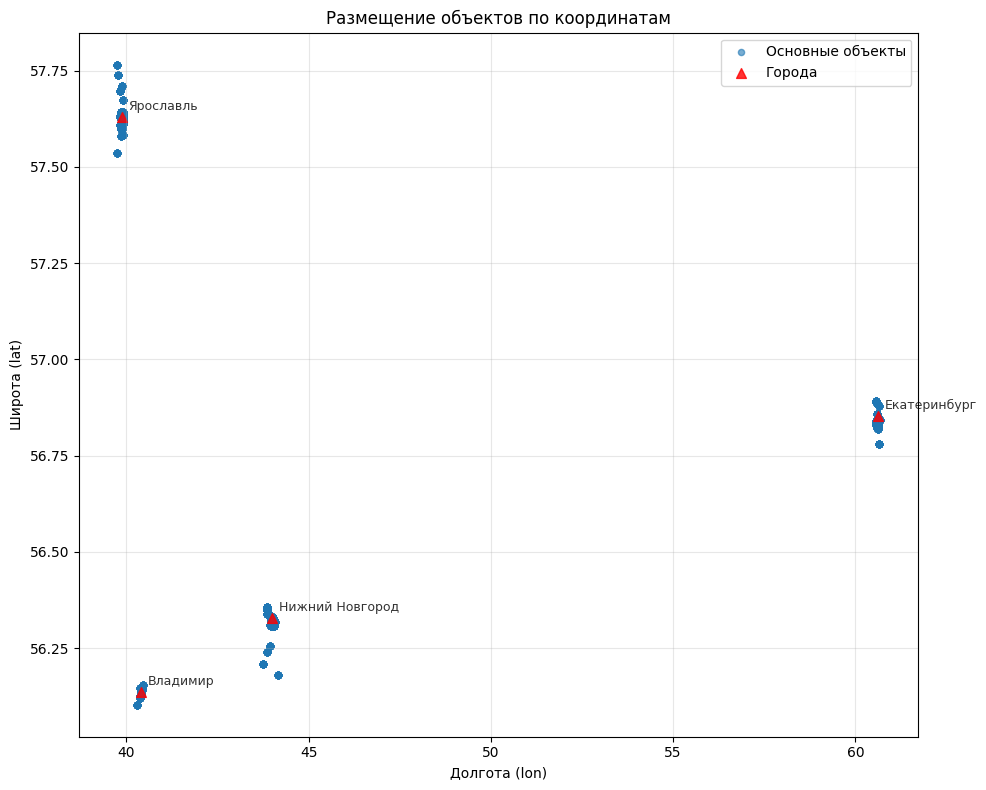

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

# Создаем DataFrame из дополнительных данных
additional_data = pd.DataFrame(
    {'city': ['Екатеринбург', 'Нижний Новгород', 'Владимир', 'Ярославль'],
     'Lat': [56.8519, 56.3287, 56.1366, 57.6299],
     'Lon': [60.6122, 44.0020, 40.3966, 39.8737]})

plt.figure(figsize=(10, 8))

# Отрисовка основных объектов
plt.scatter(df['Lon'], df['Lat'], alpha=0.6, s=20, label='Основные объекты')

# Отрисовка дополнительных объектов (городов)
plt.scatter(additional_data['Lon'], additional_data['Lat'], alpha=0.8, s=50,
            color='red', marker='^', label='Города')

# Добавляем подписи для городов
for i, row in additional_data.iterrows():
    plt.annotate(row['city'], (row['Lon'], row['Lat']), xytext=(5, 5),
                 textcoords='offset points', fontsize=9, alpha=0.8)

plt.xlabel('Долгота (lon)')
plt.ylabel('Широта (lat)')
plt.title('Размещение объектов по координатам')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

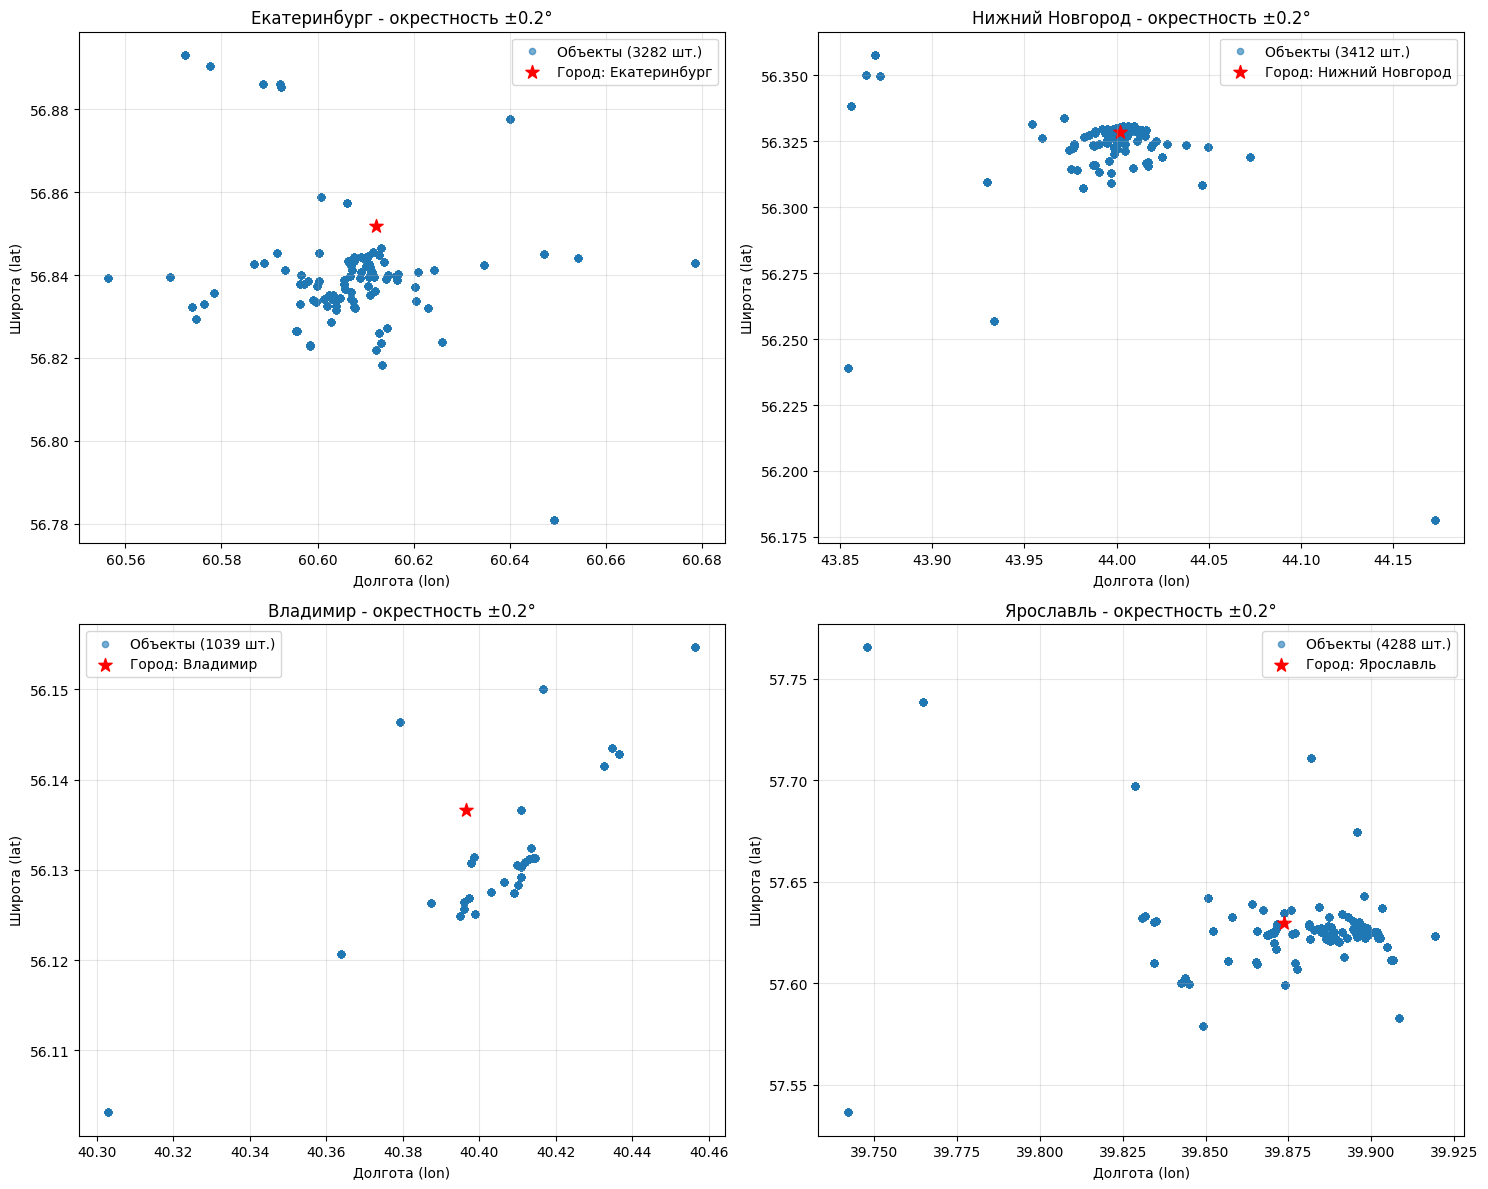

In [58]:
# Альтернативный вариант: все графики на одном изображении
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, city in additional_data.iterrows():
    # Определяем границы окрестности ±0.2 градуса
    lat_min = city['Lat'] - 0.2
    lat_max = city['Lat'] + 0.2
    lon_min = city['Lon'] - 0.2
    lon_max = city['Lon'] + 0.2

    # Фильтруем объекты из df в окрестности города
    mask = (df['Lat'] >= lat_min) & (df['Lat'] <= lat_max) & (
            df['Lon'] >= lon_min) & (df['Lon'] <= lon_max)

    filtered_df = df[mask]

    # Отрисовываем на соответствующем subplot
    axes[i].scatter(filtered_df['Lon'], filtered_df['Lat'], alpha=0.6, s=20,
                    label=f'Объекты ({len(filtered_df)} шт.)')

    axes[i].scatter(city['Lon'], city['Lat'], alpha=1.0, s=100, color='red',
                    marker='*', label=f"Город: {city['city']}")

    axes[i].set_xlabel('Долгота (lon)')
    axes[i].set_ylabel('Широта (lat)')
    axes[i].set_title(f"{city['city']} - окрестность ±0.2°")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.show()

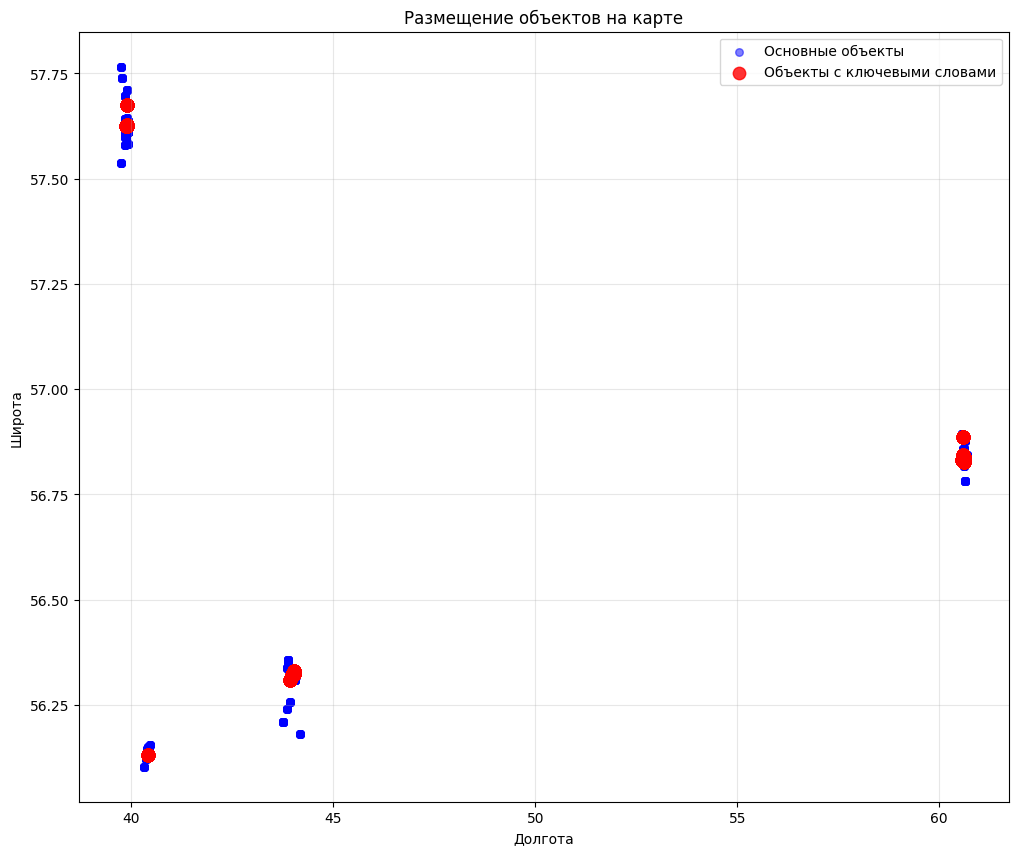

In [60]:
import pandas as pd
import matplotlib.pyplot as plt


#
# # 1. Построение графика размещения объектов
# plt.figure(figsize=(10, 8))
# plt.scatter(df['Lon'], df['Lat'], alpha=0.6, s=50, c='blue', label='Объекты')
# plt.xlabel('Долгота')
# plt.ylabel('Широта')
# plt.title('Размещение объектов на карте')
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.show()

# 2. Поиск ключевых слов в description и создание словаря
def find_keywords(description, keywords):
    """Функция для поиска ключевых слов в описании"""
    if pd.isna(description):
        return None
    description = str(description).lower()
    found_keywords = []
    for keyword in keywords:
        if keyword in description:
            found_keywords.append(keyword)
    return found_keywords if found_keywords else None


# Создаем словарь с найденными ключевыми словами
keywords_dict = {}
for idx, row in df.iterrows():
    description = row['description']
    found_keywords = find_keywords(description, type_rare)
    if found_keywords:
        keywords_dict[idx] = {'keywords': found_keywords,
                              'description': description, 'Lat': row['Lat'],
                              'Lon': row['Lon']}

# print("Найденные ключевые слова:")
# for obj_id, data in keywords_dict.items():
#     print(f"Объект {obj_id}: {data['keywords']}")

# 4. Объединенный график с основными и дополнительными данными
plt.figure(figsize=(12, 10))

# Основные объекты
plt.scatter(df['Lon'], df['Lat'], alpha=0.5, s=30, c='blue',
            label='Основные объекты')

# Объекты с найденными ключевыми словами
if keywords_dict:
    keyword_lons = [data['Lon'] for data in keywords_dict.values()]
    keyword_lats = [data['Lat'] for data in keywords_dict.values()]
    plt.scatter(keyword_lons, keyword_lats, alpha=0.8, s=80, c='red',
                label='Объекты с ключевыми словами')

plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.title('Размещение объектов на карте')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [61]:
# Дополнительно: статистика по найденным ключевым словам
if keywords_dict:
    keyword_counts = {}
    for data in keywords_dict.values():
        for keyword in data['keywords']:
            keyword_counts[keyword] = keyword_counts.get(keyword, 0) + 1

    print("\nСтатистика найденных ключевых слов:")
    for keyword, count in keyword_counts.items():
        print(f"{keyword}: {count} раз(а)")


Статистика найденных ключевых слов:
гостиница: 29 раз(а)
стадион: 72 раз(а)
сад: 357 раз(а)
планетарий: 30 раз(а)
цирк: 39 раз(а)
зоопарк: 57 раз(а)


### Поиск мусора в description

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
# import pymorphy2

# Скачиваем русские стоп-слова (если еще не скачаны)
import nltk

nltk.download('stopwords')

# Получаем русские стоп-слова
russian_stop_words = stopwords.words('russian')

# Добавляем дополнительные стоп-слова, характерные для описаний достопримечательностей
additional_stop_words = ['россия', 'город', 'находиться', 'располагаться',
                         'являться', 'также', 'например', 'который', 'мочь',
                         'один', 'год', 'время']
# russian_stop_words.extend(additional_stop_words)
# Инициализация векторйзера с базовой предобработкой
# min_df отсекает слишком редкие слова, max_df - слишком частые (но мы их тоже посмотрим)

vectorizer = TfidfVectorizer(stop_words=russian_stop_words, # Русские стоп-слова
                             max_features=1000,  # Рассмотрим топ-1000 слов
                             min_df=2,
                             # Слово должно встретиться минимум в 2 документах
                             max_df=0.8,
                             # Исключаем слова, встречающиеся в >80% документов (как стоп-слова)
                             ngram_range=(1, 2),
                             # Учитываем не только отдельные слова, но и пары (биграммы)
                             analyzer='word',  # Анализируем по словам
                             lowercase=True,  # Приводим к нижнему регистру
                             )

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\k142\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [63]:
import numpy as np

# Применяем TF-IDF
tfidf_matrix = vectorizer.fit_transform(df['description'])

# Получаем названия признаков (слова/биграммы)
feature_names = vectorizer.get_feature_names_out()

# Вычисляем средний TF-IDF для каждого слова по всем документам
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

# Создаем DataFrame для анализа
tfidf_df = pd.DataFrame(
    {'feature': feature_names, 'mean_tfidf': mean_tfidf}).sort_values(
    'mean_tfidf', ascending=False)

In [64]:
# Посмотрим на топ-20 самых "важных" слов (высокий средний TF-IDF)
print("Топ-20 слов с наивысшим TF-IDF:")
print(tfidf_df.head(20))

Топ-20 слов с наивысшим TF-IDF:
                    feature  mean_tfidf
982               ярославле    0.061273
295           екатеринбурге    0.058870
916                    храм    0.044177
928          храм ярославле    0.036085
693            православный    0.035165
631                памятник    0.034393
697       православный храм    0.033272
535                   музей    0.029968
942                 церковь    0.024253
326                  здание    0.023773
249                     дом    0.021800
51                    башня    0.020434
638  памятник екатеринбурге    0.019363
598               новгороде    0.018251
586        нижнем новгороде    0.018251
585                  нижнем    0.018251
518               монастырь    0.018190
540     музей екатеринбурге    0.018144
330    здание екатеринбурге    0.017824
429                  кремля    0.016293


In [65]:

# И на 20 самых "неважных" (низкий TF-IDF)
print("\nТоп-20 слов с наинизшим TF-IDF:")
print(tfidf_df.tail(20))


Топ-20 слов с наинизшим TF-IDF:
                      feature  mean_tfidf
100                    видную    0.000375
101               видную роль    0.000375
870             турецкого ига    0.000375
620              освобождении    0.000375
170       генерала инфантерии    0.000375
169                  генерала    0.000375
621     освобождении болгарии    0.000375
161       выдающегося учёного    0.000375
539              музей городе    0.000375
241              деятельности    0.000375
160               выдающегося    0.000375
242  деятельности выдающегося    0.000375
498        мемориальный музей    0.000375
688               посвящённый    0.000375
689         посвящённый жизни    0.000375
313                     жизни    0.000375
314        жизни деятельности    0.000375
194          городе владимире    0.000375
109     владимире посвящённый    0.000375
836         сыгравшего видную    0.000375


### Поиск мусора en_txt

In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer
# import pymorphy2

# Скачиваем русские стоп-слова (если еще не скачаны)
import nltk

nltk.download('stopwords')

vectorizer = TfidfVectorizer(stop_words='english',  # Русские стоп-слова
                             max_features=1000,  # Рассмотрим топ-1000 слов
                             min_df=2,
                             # Слово должно встретиться минимум в 2 документах
                             max_df=0.8,
                             # Исключаем слова, встречающиеся в >80% документов (как стоп-слова)
                             ngram_range=(1, 2),
                             # Учитываем не только отдельные слова, но и пары (биграммы)
                             analyzer='word',  # Анализируем по словам
                             lowercase=True,  # Приводим к нижнему регистру
                             )

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\k142\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [67]:
import numpy as np

# Применяем TF-IDF
tfidf_matrix = vectorizer.fit_transform(df['en_txt'])

# Получаем названия признаков (слова/биграммы)
feature_names = vectorizer.get_feature_names_out()

# Вычисляем средний TF-IDF для каждого слова по всем документам
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

# Создаем DataFrame для анализа
tfidf_df = pd.DataFrame(
    {'feature': feature_names, 'mean_tfidf': mean_tfidf}).sort_values(
    'mean_tfidf', ascending=False)

In [68]:
# Посмотрим на топ-20 самых "важных" слов (высокий средний TF-IDF)
print("Топ-20 слов с наивысшим TF-IDF:")
print(tfidf_df.head(20))

Топ-20 слов с наивысшим TF-IDF:
            feature  mean_tfidf
110        building    0.070168
7            arafed    0.061384
453           large    0.046563
242           clock    0.044971
916            view    0.042362
34      arafed view    0.038284
958           white    0.037677
869           tower    0.036387
200          church    0.035389
384           green    0.033735
121  building clock    0.031621
246     clock tower    0.029392
959  white building    0.027376
459  large building    0.026662
690            roof    0.025082
809         steeple    0.022494
925      view large    0.022288
501             man    0.021005
799          statue    0.020443
393      green roof    0.020252


In [69]:

# И на 20 самых "неважных" (низкий TF-IDF)
print("\nТоп-20 слов с наинизшим TF-IDF:")
print(tfidf_df.tail(20))


Топ-20 слов с наинизшим TF-IDF:
              feature  mean_tfidf
950    wall paintings    0.000391
537       middle town    0.000391
671       riding bike    0.000389
450         lamp post    0.000388
784        stand line    0.000384
736    sitting chairs    0.000382
910     uniform stand    0.000381
278          crystals    0.000375
427        house blue    0.000374
295   display various    0.000372
661         red fence    0.000371
213        church lit    0.000370
654  priests standing    0.000370
106            broken    0.000362
931        view stage    0.000362
581        park river    0.000361
772     stadium green    0.000354
973       white table    0.000350
478    leading grassy    0.000341
664          red line    0.000323


In [70]:
import pandas as pd
import re

junc_words = ["wall paintings", "middle town", "riding bike", "lamp post",
              "stand line", "sitting chairs", "uniform stand", "crystals",
              "house blue", "display various", "red fence", "church lit",
              "priests standing", "broken", "view stage", "park river",
              "stadium green", "white table", "leading grassy", "red line"]
# Создаем регулярное выражение из списка слов
pattern = '|'.join([re.escape(word) for word in junc_words])
df['is_junc_words'] = False
df['is_junc_words'] = df['en_txt'].str.contains(pattern, case=False, na=False)


def find_matching_text(text):
    if pd.isna(text):
        return None
    for word in junc_words:
        if word.lower() in str(text).lower():
            return word
    return None


df['found_text'] = df['en_txt'].apply(find_matching_text)

C:\Users\k142\AppData\Local\Temp\ipykernel_22368\2919083209.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_junc_words'] = False
C:\Users\k142\AppData\Local\Temp\ipykernel_22368\2919083209.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_junc_words'] = df['en_txt'].str.contains(pattern, case=False, na=False)
C:\Users\k142\AppData\Local\Temp\ipykernel_22368\2919083209.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

In [71]:
df[df['is_junc_words']]

,Num,Name,WikiData,City,Lon,Lat,description,image,en_txt,is_junc_words,found_text
198,198,Дом-музей Бажова,Q4290214,Екатеринбург,60.613415,56.818394,Мемориальный дом-музей П. П. Бажова,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a table with a white table cloth and ...,True,white table
347,347,Суворовское училище,Q4174329,Екатеринбург,60.647209,56.845078,военно-учебное заведение в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed group of military men in uniform standi...,True,uniform stand
348,348,Суворовское училище,Q4174329,Екатеринбург,60.647209,56.845078,военно-учебное заведение в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are many people in uniform standing in a...,True,uniform stand
349,349,Суворовское училище,Q4174329,Екатеринбург,60.647209,56.845078,военно-учебное заведение в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed military men in uniform stand in a line...,True,uniform stand
352,352,Суворовское училище,Q4174329,Екатеринбург,60.647209,56.845078,военно-учебное заведение в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAICAgICAQICAg...,arafed image of a group of men in uniform stan...,True,uniform stand
...,...,...,...,...,...,...,...,...,...,...,...
14525,4263,Ярославский филиал Военно-космической академии...,Q4538913,Ярославль,39.877613,57.607079,высшее военное училище в России,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed female soldiers in uniform stand in a line,True,uniform stand
14531,4269,Ярославский филиал Военно-космической академии...,Q4538913,Ярославль,39.877613,57.607079,высшее военное училище в России,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,a group of men in uniform stand in front of a ...,True,uniform stand
14533,4271,Ярославский филиал Военно-космической академии...,Q4538913,Ярославль,39.877613,57.607079,высшее военное училище в России,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,soldiers in uniform stand in a line in front o...,True,uniform stand
14534,4272,Ярославский филиал Военно-космической академии...,Q4538913,Ярославль,39.877613,57.607079,высшее военное училище в России,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed group of men in uniform standing in a line,True,uniform stand


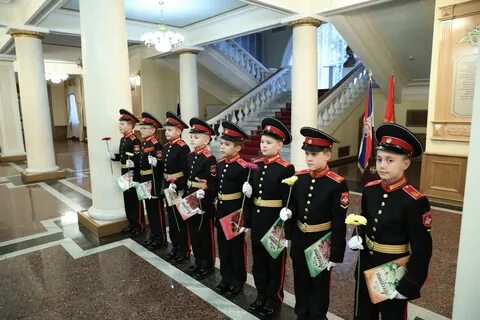

In [72]:
get_image(df.at[366, 'image'])

In [73]:
df[df['is_junc_words']].iloc[101].name

14531

In [88]:
import base64
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


def show_image_blocks_8x1(df, num_blocks=30, start_index=0, figsize=(16, 2), image_size=(64, 64)):
    """
    Показывает блоки изображений 8x1 из DataFrame с уменьшенным размером

    Parameters:
    - df: DataFrame с колонкой 'image' содержащей base64 строки
    - num_blocks: количество блоков для показа (по умолчанию 1)
    - start_index: начальный индекс в DataFrame (по умолчанию 0)
    - figsize: размер фигуры (по умолчанию (16, 2))
    - image_size: размер для ресайза изображений (по умолчанию (64, 64))
    """

    for block_num in range(num_blocks):
        # Создаем фигуру для одной линии (1x8)
        fig, axes = plt.subplots(1, 8, figsize=figsize)

        # Если axes не является массивом, преобразуем в массив для единообразия
        if not hasattr(axes, '__iter__'):
            axes = [axes]

        # Вычисляем начальный индекс для текущего блока
        current_start = start_index + (block_num * 8)

        for i in range(8):
            idx = current_start + i

            # Проверяем, что индекс в пределах DataFrame
            if idx >= len(df):
                axes[i].axis('off')
                continue

            try:
                # Декодируем и загружаем изображение
                image_data = base64.b64decode(df.iloc[idx]['image'])
                image = Image.open(BytesIO(image_data)).convert('RGB')

                # Уменьшаем размер изображения для экономии памяти
                image = image.resize(image_size, Image.Resampling.LANCZOS)

                # Показываем изображение
                axes[i].imshow(np.array(image))
                found_text = str(df.iloc[idx].name) + ':' + df.iloc[idx]['found_text']
                # Обрезаем длинный текст для заголовка
                title_text = found_text if len(found_text) <= 15 else found_text[:12] + "..."
                axes[i].set_title(f'{title_text}', fontsize=8)
                axes[i].axis('off')

            except Exception as e:
                print(f"Ошибка при загрузке изображения {idx}: {e}")
                axes[i].axis('off')
                axes[i].set_title(f'Error', fontsize=6)

        plt.tight_layout()
        plt.show()

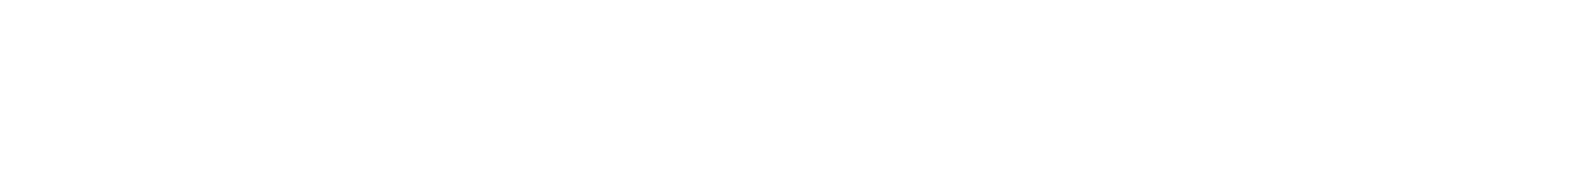

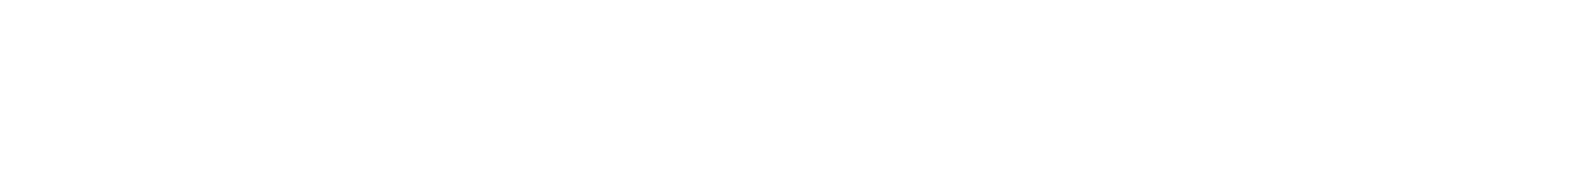

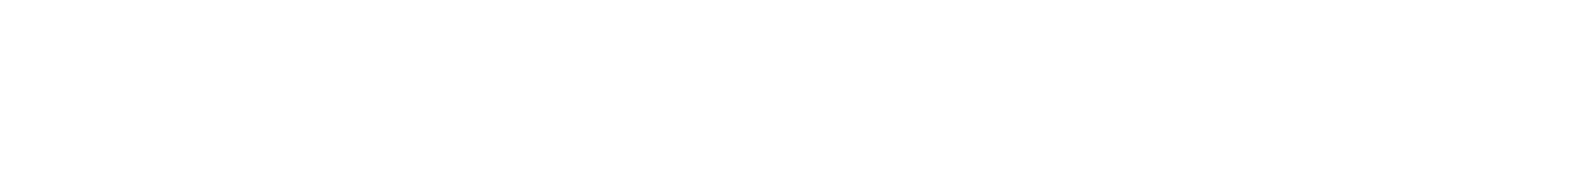

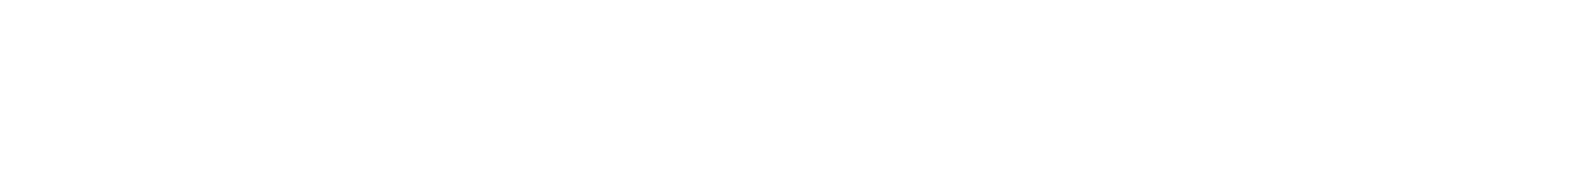

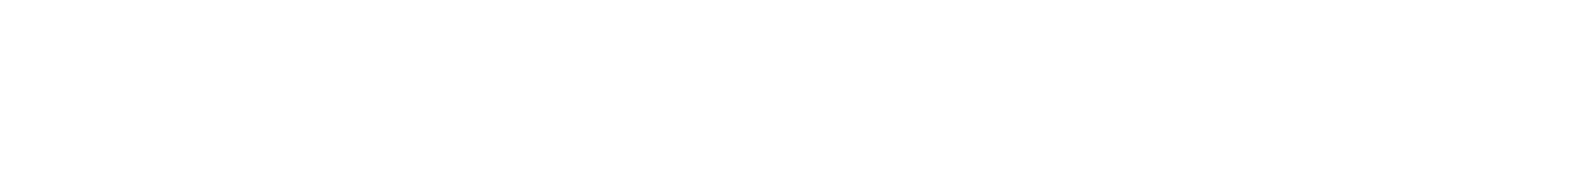

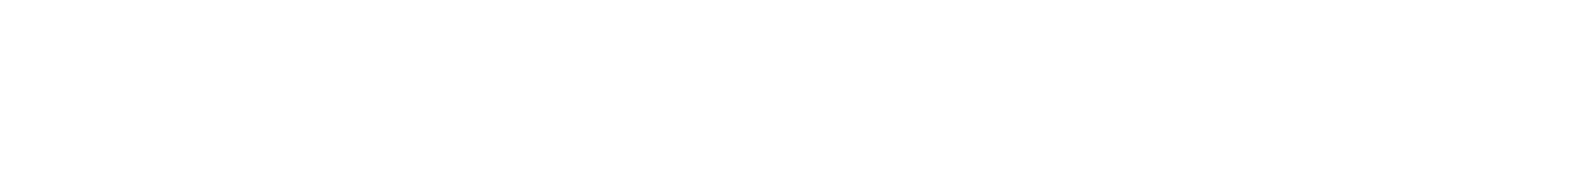

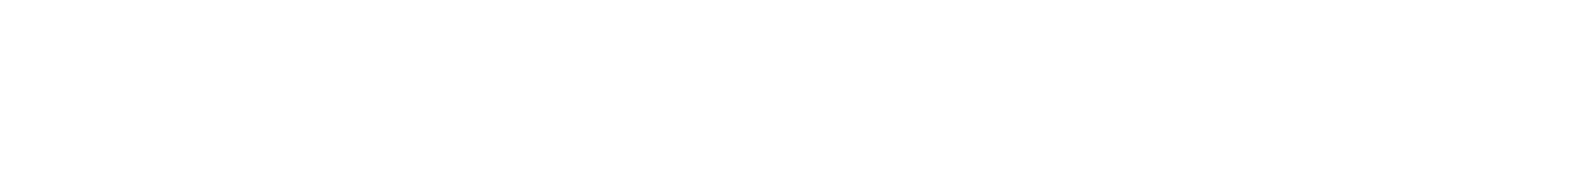

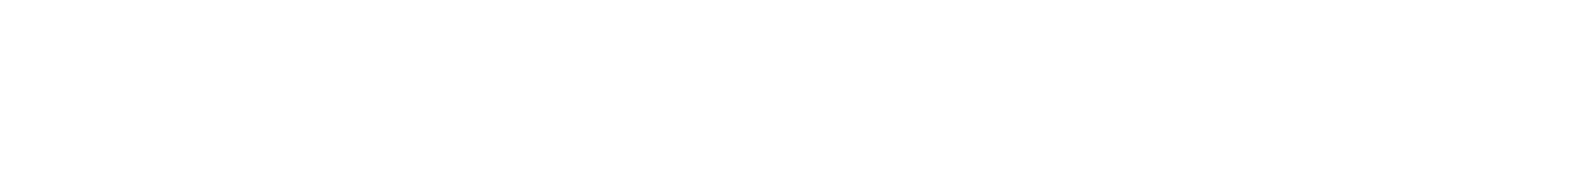

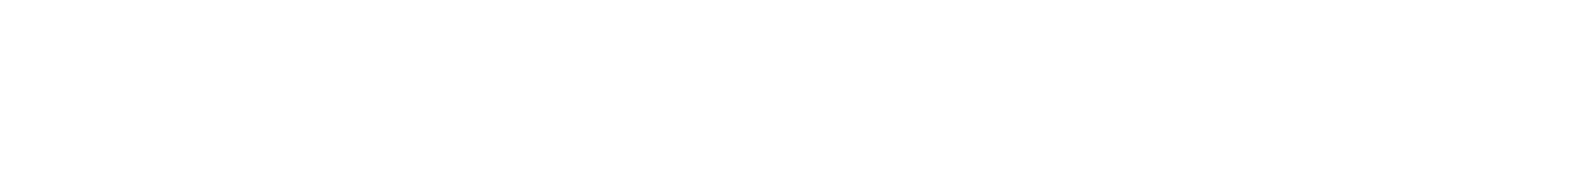

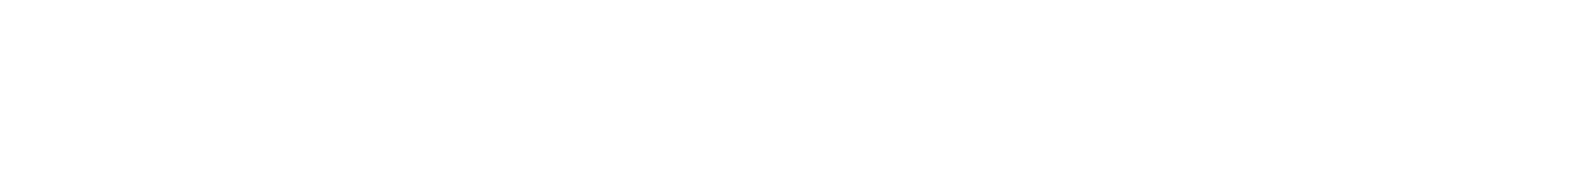

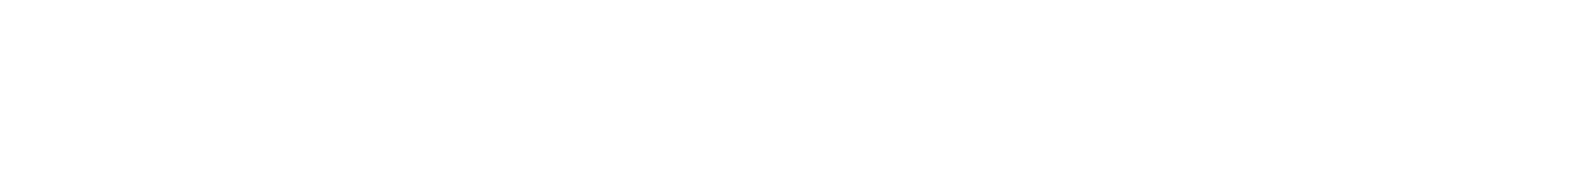

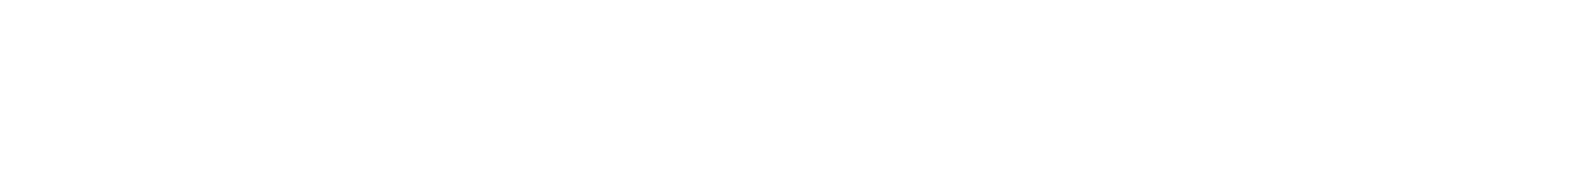

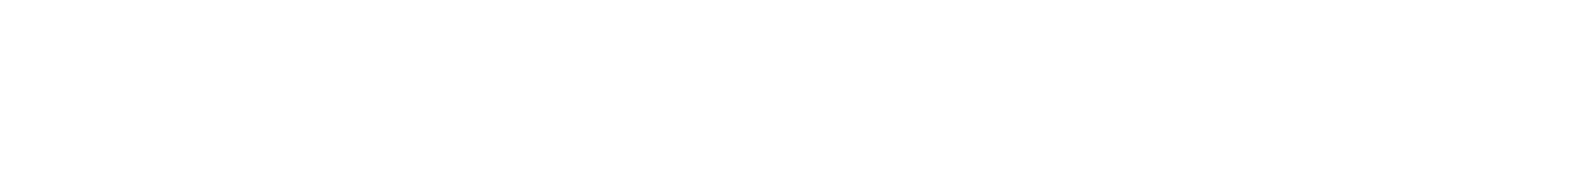

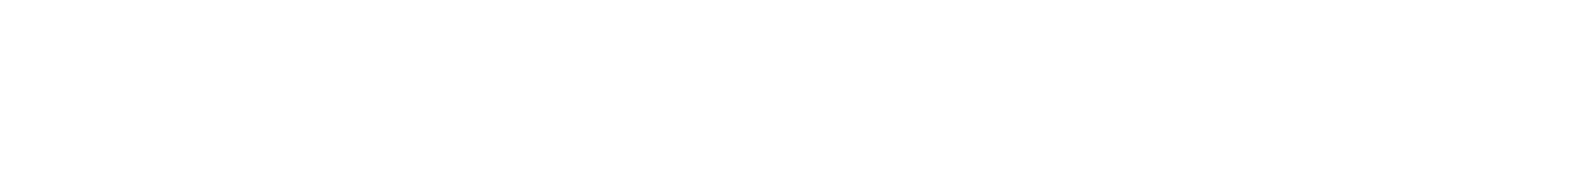

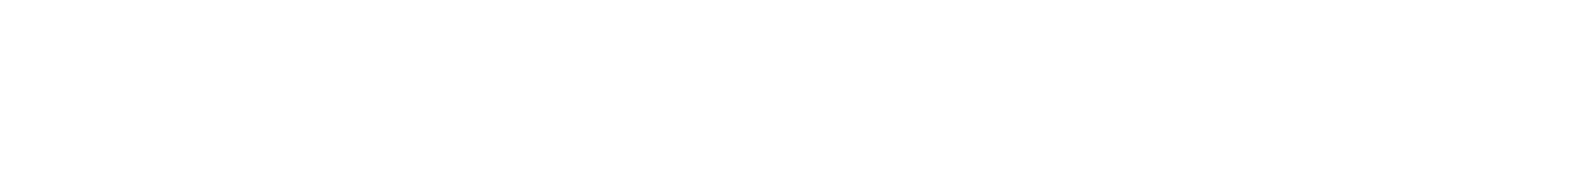

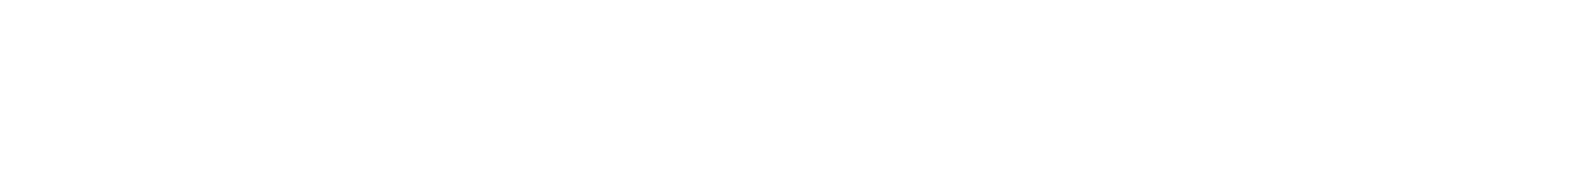

In [91]:
show_image_blocks_8x1(df[df['is_junc_words']], num_blocks=16)  # покажет 2 блока по 16 изображений

> Эти данные безболезнено можно удалить - они слабо относятся к достопримечательностям города.

In [90]:
df = df[~df['is_junc_words']]

# Отбор 100

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [ ]:
type_freq = ['дом', 'церковь', 'музей', 'памятник', 'собор', 'башня', 'театр',
             'улица', 'парк', 'монастырь', 'усадьба', 'университет', 'мост',
             'храм']
type_rare = ['сад', 'сквер', 'гостиница', 'стадион', 'зоопарк', 'цирк',
             'планетарий']

есть набор df

df.info()
```
<class 'pandas.core.frame.DataFrame'>
Index: 12078 entries, 0 to 14633
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Num          12078 non-null  int64
 1   Name         12078 non-null  object
 2   WikiData     12078 non-null  object
 3   City         12078 non-null  object
 4   Lon          12078 non-null  float64
 5   Lat          12078 non-null  float64
 6   description  12078 non-null  object
 7   image        12078 non-null  object
 8   en_txt       12078 non-null  object
dtypes: float64(2), int64(1), object(6)
memory usage: 943.6+ KB
df.City.unique()
array(['Екатеринбург', 'Нижний Новгород', 'Владимир', 'Ярославль'],
      dtype=object)
```

надо отобрать 150 записей со страфикацией по каждому городу и названию Name.
```
type_freq = ['дом', 'церковь', 'музей', 'памятник', 'собор', 'башня', 'театр',
             'улица', 'парк', 'монастырь', 'усадьба', 'университет', 'мост',
             'храм']
type_rare = ['сад', 'сквер', 'гостиница', 'стадион', 'зоопарк', 'цирк',
             'планетарий']
```
поле description должно содержать частые названия типа достопримечательности из списка type_freq и единичные из списка type_rare

выбрать наиболее представимые по длине описания


In [92]:
import pandas as pd
import numpy as np

# Функция для определения типа достопримечательности по названию
def get_attraction_type(name):
    name_lower = name.lower()

    # Сначала проверяем редкие типы
    for rare_type in type_rare:
        if rare_type in name_lower:
            return rare_type

    # Затем частые типы
    for freq_type in type_freq:
        if freq_type in name_lower:
            return freq_type

    return 'other'

# Добавляем столбец с типом достопримечательности
df['attraction_type'] = df['Name'].apply(get_attraction_type)

# Функция для вычисления длины описания (учитываем только русские символы)
def count_russian_chars(text):
    russian_letters = set('абвгдеёжзийклмнопрстуфхцчшщъыьэюя')
    return sum(1 for char in str(text).lower() if char in russian_letters)

df['description_length'] = df['description'].apply(count_russian_chars)

# Фильтруем только нужные типы (исключаем 'other')
valid_types = type_freq + type_rare
df_filtered = df[df['attraction_type'].isin(valid_types)].copy()

In [ ]:

# Функция для стратифицированной выборки
def stratified_sample(df, n_total=150):
    cities = df['City'].unique()
    samples_per_city = n_total // len(cities)

    sampled_dfs = []

    for city in cities:
        city_df = df[df['City'] == city]

        # Распределяем выборку по типам внутри города
        types_in_city = city_df['attraction_type'].unique()
        base_samples_per_type = samples_per_city // len(types_in_city)
        remainder = samples_per_city % len(types_in_city)

        city_samples = []

        for i, attr_type in enumerate(types_in_city):
            type_df = city_df[city_df['attraction_type'] == attr_type]

            # Определяем сколько брать из этого типа
            n_samples = base_samples_per_type
            if i < remainder:
                n_samples += 1

            if len(type_df) >= n_samples:
                # Выбираем наиболее представительные по длине описания
                # Берем записи с длиной описания близкой к медиане
                median_length = type_df['description_length'].median()
                type_df = type_df.copy()
                type_df['length_diff'] = abs(type_df['description_length'] - median_length)
                sampled_type = type_df.nsmallest(n_samples, 'length_diff')
            else:
                # Если записей меньше, чем нужно, берем все
                sampled_type = type_df

            city_samples.append(sampled_type)

        sampled_dfs.extend(city_samples)

    result_df = pd.concat(sampled_dfs, ignore_index=True)

    # Если общее количество не равно n_total, делаем корректировку
    if len(result_df) > n_total:
        # Удаляем лишние записи, начиная с наименее репрезентативных
        result_df = result_df.nlargest(n_total, 'description_length')
    elif len(result_df) < n_total:
        # Добавляем недостающие записи из наиболее репрезентативных
        additional_needed = n_total - len(result_df)
        remaining_df = df[~df.index.isin(result_df.index)]
        additional_samples = remaining_df.nlargest(additional_needed, 'description_length')
        result_df = pd.concat([result_df, additional_samples], ignore_index=True)

    return result_df

# Выполняем стратифицированную выборку
sampled_df = stratified_sample(df_filtered, 150)

# Проверяем распределение
print("Распределение по городам:")
print(sampled_df['City'].value_counts())
print("\nРаспределение по типам достопримечательностей:")
print(sampled_df['attraction_type'].value_counts())

# Удаляем вспомогательные столбцы
sampled_df = sampled_df.drop(['attraction_type', 'description_length'], axis=1)

print(f"\nИтоговый размер выборки: {len(sampled_df)} записей")

In [93]:
# Простой подход - пропорциональная стратификация
def simple_stratified_sample(df, n_total=150):
    # Вычисляем веса для стратификации
    city_weights = df['City'].value_counts(normalize=True)
    df['weight'] = df['City'].map(city_weights)

    # Сортируем по репрезентативности (длине описания)
    df_sorted = df.sort_values('description_length', ascending=False)

    # Выбираем лучшие записи с учетом весов городов
    sampled_indices = []
    city_quotas = (city_weights * n_total).round().astype(int)

    for city, quota in city_quotas.items():
        city_df = df_sorted[df_sorted['City'] == city].head(quota)
        sampled_indices.extend(city_df.index)

    result_df = df_sorted.loc[sampled_indices].head(n_total)
    return result_df.reset_index(drop=True)

# Использование простого подхода
df['description_length'] = df['description'].apply(count_russian_chars)
sampled_simple = simple_stratified_sample(df_filtered, 150)

In [94]:
sampled_simple

,Num,Name,WikiData,City,Lon,Lat,description,image,en_txt,is_junc_words,found_text,attraction_type,description_length,weight
0,2717,Толгский Ярославский в честь Введения во храм ...,Q1776349,Ярославль,39.828690,57.697281,Женский православный монастырь Ярославской епа...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,snowy landscape of a large white building with...,False,None,монастырь,46,0.335674
1,2716,Толгский Ярославский в честь Введения во храм ...,Q1776349,Ярославль,39.828690,57.697281,Женский православный монастырь Ярославской епа...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed room with a long table and a bench in it,False,None,монастырь,46,0.335674
2,2771,Толгский Ярославский в честь Введения во храм ...,Q1776349,Ярославль,39.828690,57.697281,Женский православный монастырь Ярославской епа...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a fountain in front of a buildi...,False,None,монастырь,46,0.335674
3,2754,Толгский Ярославский в честь Введения во храм ...,Q1776349,Ярославль,39.828690,57.697281,Женский православный монастырь Ярославской епа...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a church with a green roof and ...,False,None,монастырь,46,0.335674
4,2748,Толгский Ярославский в честь Введения во храм ...,Q1776349,Ярославль,39.828690,57.697281,Женский православный монастырь Ярославской епа...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a large white building with a g...,False,None,монастырь,46,0.335674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,190,Дом-музей Столетовых,Q107422934,Владимир,40.413654,56.132446,"Мемориальный музей в городе Владимире, посвящё...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a small house with a red roof and a w...,False,None,дом,184,0.081300
146,191,Дом-музей Столетовых,Q107422934,Владимир,40.413654,56.132446,"Мемориальный музей в городе Владимире, посвящё...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue building with a red roof and a...,False,None,дом,184,0.081300
147,194,Дом-музей Столетовых,Q107422934,Владимир,40.413654,56.132446,"Мемориальный музей в городе Владимире, посвящё...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,snowy scene of a building with a clock tower a...,False,None,дом,184,0.081300
148,214,Дом-музей Столетовых,Q107422934,Владимир,40.413654,56.132446,"Мемориальный музей в городе Владимире, посвящё...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed man standing in front of a blue buildin...,False,None,дом,184,0.081300


In [ ]:
sampled_simple

aЗдесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

In [ ]:
# your code here

Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [ ]:
# your code here

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

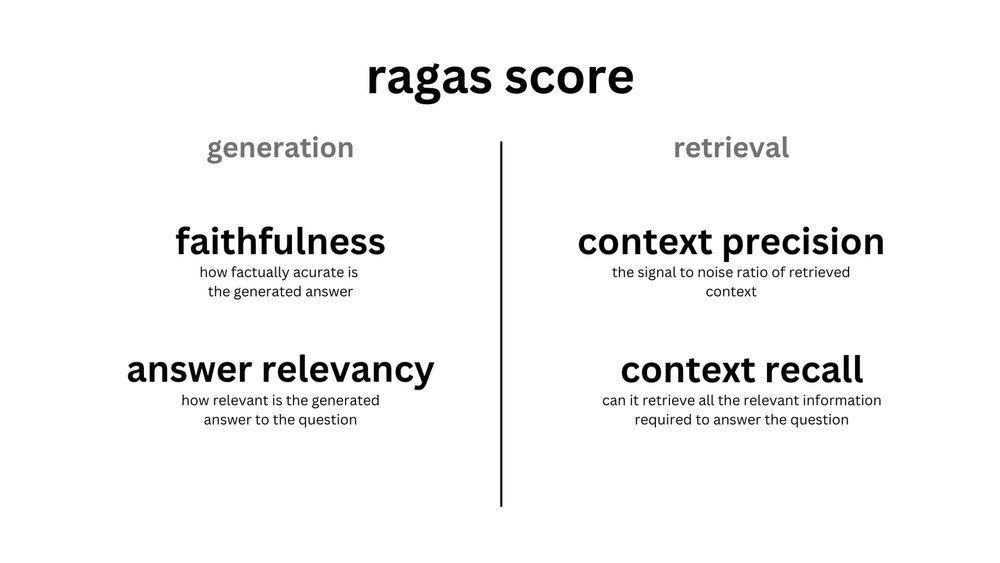

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [ ]:
def data_preprocess(...):
    # your code here
    return ...

In [ ]:
def answer_relevancy(...):
    # your code here
    return ...

# Протестируйте ваш RAG (3 балла)

In [ ]:
# your code here

# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [ ]:
# your code here